In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import uniform
from scipy import stats

In [2]:
def plot_p_values(m,alpha):
    uniform_distribution = uniform(loc=1, scale=m-1)
    x = np.linspace(uniform_distribution.ppf(0), uniform_distribution.ppf(1), m)
    cdf = uniform_distribution.cdf(x)
    #plt.plot(x, cdf, 'k-', lw=2,label='cdf under null')

    data = uniform.rvs(loc=0, scale=1, size=m, random_state=12)
    filtered = filter(lambda x: x[1] <= alpha*(x[0]+1)/m, enumerate(np.sort(data)))
    filtered = list(filtered)
    R = max(filtered)[0] + 1 if filtered else 0
    plt.plot([i for i in range(1, R+1)], np.sort(data)[0:R], 'o', color='red')
    plt.plot([i for i in range(R+1,m+1)], np.sort(data)[R:], 'o', color='blue')

    plt.axhline(y=alpha, color='orange', linestyle='-', label="alpha")
    plt.axhline(y=alpha/m, color='green', linestyle='-', label="alpha/m")
    plt.axhline(y=np.sort(data)[R-1], color='purple', linestyle='-', label="B-H")

    x = np.linspace(1,m,11)
    plt.plot(x, (alpha/m)*x,'b', label='alpha * k/m')

    plt.legend(loc='upper left'); plt.ylabel("Pk");plt.xlabel("k");
    plt.title("Sorted p-values")

def bh():
    alpha = 0.05
    m = 50
    k = np.arange(1, m+1)
    bh_line = alpha * k/m
    np.random.seed(seed=233401)
    pvals = np.sort(stats.beta.rvs(size=50, a=3, b=15))**2
    plt.figure(figsize=(8, 6))
    plt.plot(k, bh_line, color='b', label='alpha * k/m')
    r = np.max(np.where(pvals - alpha*k/m <= 0))
    plt.scatter(np.arange(1, r+2), pvals[0:r+1], color='red', s=25)
    plt.scatter(np.arange(r+2, m+1), pvals[r+1:m+1], color='darkblue', s=25)
    cutoff = pvals[r]
    plt.plot([r+1, r+1], [alpha/m, cutoff], color='grey')
    plt.plot([1, m], [cutoff, cutoff], color='purple', label='B-H threshold')
    plt.xlabel('$k$', size=15)
    plt.ylim(0, alpha)
    plt.legend()
    plt.title('Sorted $p$-Values, $R =$ '+str(r+1), size=20)
    print('alpha =', alpha, ' m =', m);

#### Data 188 Spring 2024 ####
# Week 12 Seminar Notes #
### A. Adhikari ###
**with Kate Gwimm, Vincent He (Fall 2022)**

# Multiple Comparisons

## Introduction

Last time, we explored the question: Given numerical data in $G$ groupswith sample size $n_{g}$ in Group $g$, is there a difference in distribution between the groups? 

In the one-way ANOVA model, the null hypothesis was that all the underlying group means are equal:

$$H^*_0 : \mu_{1} = \mu_{2} = \dots = \mu_{g}$$

This is sometimes called the *global null hypothesis* to distinguish it from hypotheses that say only that some pair or subset of the means are equal.


## Bonferroni Correction Method
Last time we developed an $F$-test for $H_0$ under some normality and independence assumptions. Another approach would be to instead do ${G \choose 2}$ comparisons, or tests:
$$
\begin{align*}
H_0^1: ~& \mu_{1} = \mu_{2}\\
H_0^2: ~& \mu_{1} = \mu_{3}\\
~& \dots \\
H_0^{G \choose 2}: ~& \mu_{G-1} = \mu_{G}
\end{align*}
$$

We call $H^{*}_{0}$ the "global null" because $H^{*}_{0}$ is the same as "all the $H^{i}_{0}$'s are true". 

The next natural question is, if we run each test at a $5\%$ level (resulting in ${G \choose 2}$ $p$ values), then what is our overall error rate?

### False Discoveries

If a test concludes the alternative when in fact the null is true, we have a *false discovery*.

Thus the level of the test $i$ is the chance that the test makes a false discovery:  

$$
\text{Level of Test } i = P^{i}_{H_{0}}\left(\text{reject } H^{i}_{0}\right)
$$

We have $\binom{G}{2}$ tests. We will denote ${G \choose 2}$ by $m$.

Tukey defined the *familywise error rate* $FWER$ as the chance of at least one false discovery.

Assuming the global null is true, so all of our $H^{i}_{0}$'s are also true, and the level of each test is $\alpha$, the familywise error rate is

$$FWER = P_{{H}^{*}_0}(\text{at least 1 false discovery}) ~=~ P_{{H}^{*}_0}(\bigcup_{i=1}^m \text{ reject } {H^{i}_{0}}) ~=~ 1 - P_{{H}^{*}_0}(\text{no false discoveries})$$

Because our tests are all based on the same samples, they are not independent. So in general, 

$$FWER ~=~ 1 - P_{{H}^{*}_0}(\text{no false discoveries}) ~\neq~ 1 - (1 - \alpha)^m$$

However, we do have a bound on $FWER$ by Boole's (or Bonferroni's) inequality. Since all $m$ tests have level $\alpha$,

$$
FWER ~=~ P_{{H}^{*}_0}(\bigcup_{i=1}^m \text{ reject } H^{i}_{0}) 
~\le~ \sum_{i=1}^m P_{{H}^{*}_0} (\text{ reject } H^{i}_{0}) ~\le~ m\alpha 
$$

The probability we want to control is the overall error rate $FWER$ on the LHS. The $m$ in our upper bound is the number of tests and is fixed. We can, however, control the level of each test. Instead of starting with level $\alpha$ for each test of ${H}^{*}_0$, if we had started with level $\frac{\alpha}{m}$ for each test, we could control $FWER$.

This is the **Bonferroni Method**: Start with a level of $\frac{\alpha}{m}$ for all $m$ tests. Then the chance that there is at least one false discovery under the global null is at most $\alpha$. 

The pros of this method are that it's easy to do and requires no assumptions about our model. The con is that when $m$ is very big, $\frac{\alpha}{m}$ is very small. Having a small cutoff for our p-values means that our rejection region is small, so the power of each test will be small. The tests will be extremely conservative.

### How bad is Bonferroni's bound?

So how conservative is each test? Let's explore the closeness of the upper bound. 

Suppose we set the level of each test to $\frac{\alpha}{m}$ and our tests are independent. Then 

$$FWER= 1 - (1 - \frac{\alpha}{m})^m$$

Let's find an exponential approximation to this chance. We know that for small $x$, $\log(1+x) \sim x$. So

$$\log(1-\alpha)^m = m\log(1-\alpha) \sim m\frac{-\alpha}{m} = -\alpha$$
and hence
$$FWER ~ = ~ 1 - (1 - \frac{\alpha}{m})^m \sim 1-e^{-\alpha}$$

Now $e^{-x} = 1 - x + \frac{x^{2}}{2!}-\dots \sim 1 - x \; \text{for small x}$. So

$$FWER = 1 - (1 - \frac{\alpha}{m})^m \sim 1-e^{-\alpha} \sim \alpha$$

We have shown that if we use the Bonferroni method and the tests are independent, then the chance of at least 1 false discovery is very close to $\alpha$. In other words, while the power of our test will still be low, we can't do much better than Bonferroni if our goal is to control $FWER$ alone.

## Benjamini–Hochberg Procedure

In some contexts, such as bioinformatics, the number of tests $m$ is sometimes huge. The Bonferroni method might lead to no discoveries at all. What if we were prepared to accept some number of false discoveries? Benjamini and Hochberg provided a procedure that is a compromise between performing each test and level $\alpha$ and performing it at level $\alpha/m$.

Today we will just describe the procedure. In the next session we will look at exactly what it is controlling.

Assume we perform $m$ tests using the Bonferroni method, so each test has level $\frac{\alpha}{m}$. Let $P_1, P_2, \dots , P_m$ be the p-values. For example, for test $k$, we will reject $H^{k}_{0}$ if $ P_k < \frac{\alpha}{m}$. Remember that each $P_k$ is a random variable: it depends on the sample.

The global null is that all $m$ null hypotheses $H^{i}_{0}, 1 \leq i \leq m$ are true. Thus we reject the global null when at least one of the p-values is less than $\frac{\alpha}{m}$ This is equivalent to rejecting the global null when the minimum p-value is less than $\frac{\alpha}{m}$. 

We've seen that this is $\frac{\alpha}{m}$ is extremely conservative. 

If we didn't use the Bonferroni method and instead used a level $\alpha$ for every test, we'd have a lot more discoveries. However the more discoveries we have, the more likely we are to have more false discoveries as well.

There must be a cutoff between $\alpha$ and $\frac{\alpha}{m}$ that is better! The figure below will help us see what is happening.

- The points are the sorted p-values $P_{(k)}$ plotted against $k$. 
- The gold line is at vertical level $\alpha$. The green line is at vertical level $\alpha/m$. Using the gold threshold corresponds to performing each test at level $\alpha$. With this threshold we reject 7 hypotheses, that is, we have 7 discoveries. 
- The green threshold corresponds to performing each test at level $\alpha/m$. With this threshold we have 3 discoveries.

**Idea (Benjamini-Hochberg):** At $k=1$, go up to the green line, that is, start at the point $(1, \alpha/m)$. At $k=m$, go up to the gold line, that is, the point $(m, \alpha)$. Join the two dots with a blue line.  Find the highest $k$ such that the corresponding p-value is at or below the blue line. That p-value becomes the new threshold, shown as the purple line.

That is, for all p-values at or below this threshold, we will reject their respective null hypotheses. The 5 points corresponding to those p-values are shown in red and correspond to the discoveries made by the Benjamini-Hochberg process. For all p-values strictly above this threshold, shown in blue, we will stick with their respective null hypotheses.

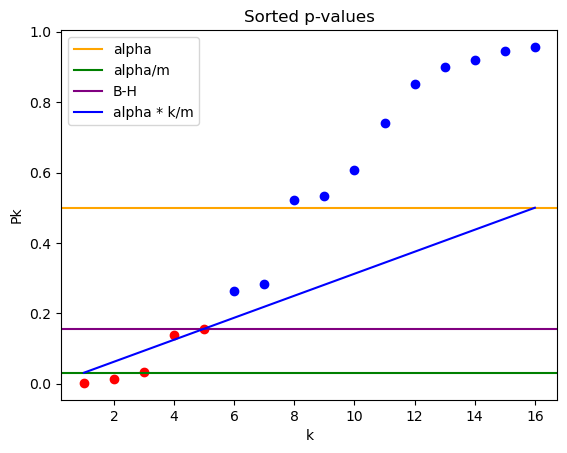

In [3]:
# Red dots correspond to p-values of the rejected hypotheses
plot_p_values(m=16,alpha=0.5)

Formally, the Benjamini-Hochberg process proposes that we reject all the hypotheses $H^{1}_0, H^{2}_0, \dots, H^{k}_0$ such that $k$ is the largest number for which $P_{(k)} < \alpha \cdot \frac{k}{m}$. 

### Setup and Notation
We are testing $m$ null hypotheses $H_0^1, H_0^2, \ldots, H_0^m$.

Let the corresponding p-values be $P_1, P_2, \ldots, P_m$ with order statistics $P_{(1)}, P_{(2)}, \ldots, P_{(m)}$.

Let $R$ be the number of discoveries, that is, the number of rejected null hypotheses. Let $V$ be the number of true null hypotheses that are rejected, that is, the number of false discoveries.

The *false discovery proportion* $FDP$ is defined by
$$
FDP = 
\begin{cases}
\displaystyle{\frac{V}{R}} & \text{if } R > 0 \\
0 & \text{if } R = 0
\end{cases}
$$
This is more compactly written as
$$
FDP = \frac{V}{\max(R, 1)}
$$

The $FDP$ is a ratio of random counts. Benjamini and Hochberg defined its expectation to be the *false discovery rate* $FDR$:

$$
FDR ~ = ~ E(FDP)
$$

The Benjamini-Hochberg (B-H) procedure controls the $FDR$ to be at most $\alpha$, as we will show below. Before we do that, recall a situation in which you would want to consider B-H. Suppose you are testing a large number of null hypotheses, only a few of which are true – and you really want to discover which ones are true. Then you might want to use B-H to have a higher chance of making the discoveries than you'd have if you were using the Bonferroni method, even though you would make more false discoveries along the way.

### B-H Procedure
As described in the last seminar, the process is:

- Find the largest $k$ for which $P_{(k)} \le \displaystyle{\frac{\alpha k}{m}}$. Call that index $k^*$.
- Reject all the null hypotheses corresponding to $P_{(1)}, P_{(2)}, \ldots, P_{(k^*)}$.
- Accept all the other null hypotheses.

Thus $k^*$ discoveries are made. In our new notation, $k^* = R$.

The figure below is a version of the one from last week and shows how the procedure works. The red points correspond to the discoveries, that is, the rejected null hypotheses.

alpha = 0.05  m = 50


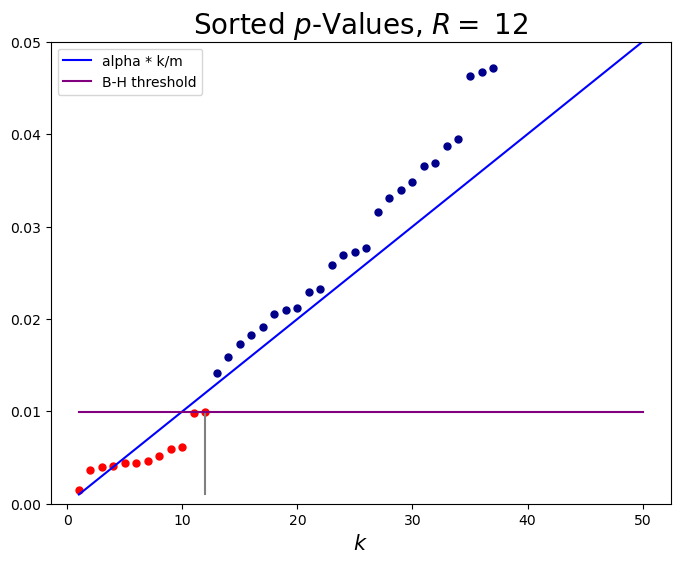

In [4]:
bh()

The question now is how many of the rejected null hypotheses are actually false, or, by complementation, how many of the rejections are false rejections.

The $FDP$ is the proportion of red points that are false rejections. This is a random proportion: both its numerator and denominator are random. By definition, the $FDR$ is the expectation of the random proportion of false discoveries.

### Proof of $FDR$ Control

The Benjamini-Hochberg procedure controls the $FDR$ to be at most $\alpha$. 

We will prove this result in the case where the p-values are independent and continuous so they have no ties. More general proofs are provided in advanced classes including Stat 210A.

For some $m_0 \le m$ suppose $m_0$ of the null hypotheses are true. Let $\mathcal{H_0} = \{i: H_0^i \text{ is true}\}$ be the set of indices of the true null hypotheses. Then $\mathcal{H_0}$ has $m_0$ elements.

For $1 \le i \le m$ let $V_i = I(H_0^i \text{ is rejected})$. Then we can write the $FDP$ as

$$
FDP ~ = ~ \frac{V}{\max(R, 1)} ~ = ~ \frac{\sum_{i \in \mathcal{H}_0} V_i}{\max(R, 1)}
$$
So
$$
FDR ~ = ~ \sum_{i \in \mathcal{H}_0} E \left( \frac{V_i}{\max(R, 1)} \right)
$$

Suppose we are able to show that for each $i \in \mathcal{H}_0$, 

$$
E \left( \frac{V_i}{\max(R, 1)} \right) \le \frac{\alpha}{m}
$$

Then we'll be done because the bound will imply

$$
FDR ~ \leq ~ m_0 \cdot \frac{\alpha}{m} ~ \leq \alpha
$$

So let's fix $i \in \mathcal{H}_0$. We have 

$$
E \left(\frac{V_i}{\max(R, 1)} \right)
~ = ~ E \left( \frac{I(H_0^i \text{ is rejected})}{\max(R, 1)} \right)
~ = ~ E \left( \frac{I(P_i \le \alpha R/m)}{\max(R, 1)} \right)
$$

because the condition for rejection is $P_i \le \displaystyle{\frac{\alpha k^*}{m}} = \displaystyle{\frac{\alpha R}{m}}$.

If the denominator were a constant, we could pull it out of the expectation. The idea is to condition in such a way that it does become a constant we can pull out.

Take another look at the red points in the figure above. If you drop one of them to $0$, it's still below the threshold $\displaystyle{\frac{\alpha R}{m}}$, and the number of rejections is still $R$ though the threshold for rejection might have changed.

This is just what we need. To simplify notation, let $\mathbf{P}$ be the sequence $P_1, P_2, \ldots, P_m$ and let $R$ be denoted $R(\mathbf{P})$ to remind us that $R$ is a function of the p-values.

For our fixed $i \in \mathcal{H}_0$, consider the new set of p-values $\mathbf{P}_{i, 0}$ which is the sequence $\mathbf{P}$ but with $P_i$ replaced by $0$. Let $R(\mathbf{P}_{i, 0})$ be the number of rejections based on this new sequence.

Condition on $\mathbf{P}_{i,0}$:
$$
\begin{align*}
E \left(\frac{V_i}{\max(R, 1)} \right) 
~ &= ~ E \left( \frac{I(P_i \le \alpha R/m)}{\max(R, 1)} \right) \\
&= ~ E \left( E \left( \frac{I(P_i \le \alpha R/m)}{\max(R, 1)} \mid \mathbf{P}_{i, 0} \right)\right)\\
\end{align*}
$$

If we can show that the inner conditional expectation $E \left( \displaystyle{ \frac{I(P_i \le \alpha R/m)}{\max(R, 1)} } \mid \mathbf{P}_{i, 0} \right)$ is at most $\displaystyle{\frac{\alpha}{m}}$, we'll be done.

As we noticed above, on the event $\{P_i \le \alpha R/m\}$, that is, when $H_0^i$ is rejected, we have $R(\mathbf{P}) > 0$ and $R = R(\mathbf{P}) = R(\mathbf{P}_{i, 0})$.

So the inner expectation is 
$$
\begin{align*}
E \left( \frac{I(P_i \le \alpha R/m)}{\max(R, 1)} \mid \mathbf{P}_{i, 0} \right) ~ &= ~ 
\frac{1}{R}\cdot E(I(P_i \le \alpha R/m) \mid \mathbf{P}_{i,0}) \\
&= ~ \frac{1}{R} \cdot P(P_i \le \alpha R/m)
\end{align*}
$$

Keep in mind that we have assumed the p-values are independent of each other. So replacing $P_i$ by $0$ doesn't change the distribution of the other p-values, and $P_i$ is independent of $\mathbf{P}_{i,0}$.

Since $i \in \mathcal{H}_0$, the distribution of $P_i$ is uniform $(0, 1)$, and

$$
\frac{1}{R} \cdot P(P_i \le \alpha R/m) ~ = ~ \frac{1}{R} \cdot \frac{\alpha R}{m} 
~ = ~ \frac{\alpha}{m}
$$
as claimed.

Note: In the discrete setting the p-value is a discrete random variable with $P(P_i \le \alpha R/m) \le \frac{\alpha R}{m}$. So the equalities above become upper bounds.